# Optimization Methods 



So, neural networks are an optimization problem. So is linear regression. 


So for linear regression, we have a closed-form solution. Let's play around with this stuff and see how our results differ depending on if we use the gradient-based methods v.s. the closed-form.

### Lets Gen some data first

In [112]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

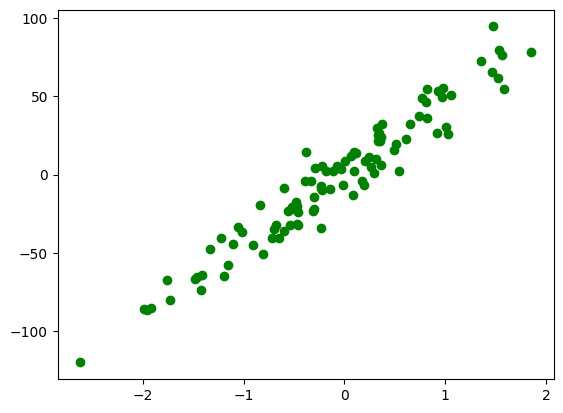

In [113]:
X, y = make_regression(n_samples=100, n_features=1, noise=12, random_state=42)
X_ones = np.hstack((X, np.ones((X.shape[0], 1))))
plt.scatter(X_ones[:, 0], y, c='green')

In [114]:
X_ones[:10] # x by the intercept term

array([[ 0.93128012,  1.        ],
       [ 0.08704707,  1.        ],
       [-1.05771093,  1.        ],
       [ 0.31424733,  1.        ],
       [-0.47917424,  1.        ],
       [ 0.64768854,  1.        ],
       [-0.46341769,  1.        ],
       [ 0.54256004,  1.        ],
       [ 0.61167629,  1.        ],
       [ 1.0035329 ,  1.        ]])

### Analytical Solution

Lets first get the closed form solution

In [115]:
import numpy as np

w_true = (np.linalg.inv(X_ones.T @ X_ones) @ X_ones.T) @ np.expand_dims(y, 1)
w_true.shape

(2, 1)

In [116]:
#the true w is [coef, intercept]
w_true

array([[44.97638393],
       [ 1.39813838]])

### Lets plot them 

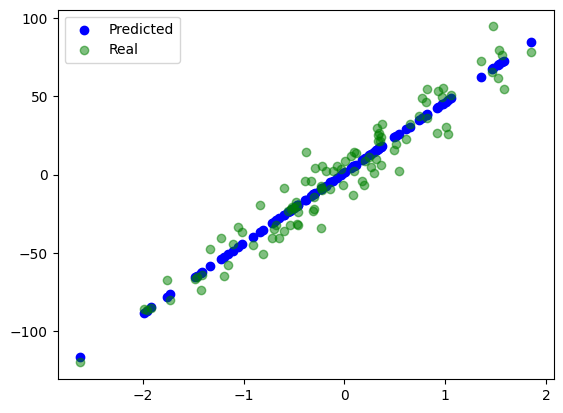

In [117]:
y_hat = w_true[0] * X_ones[:, 0] + w_true[1]
plt.scatter(X_ones[:, 0], np.squeeze(y_hat), c='blue', label='Predicted')
#vs real
plt.scatter(X_ones[:, 0], y, c='green', alpha=0.5, label='Real') 
plt.legend()    

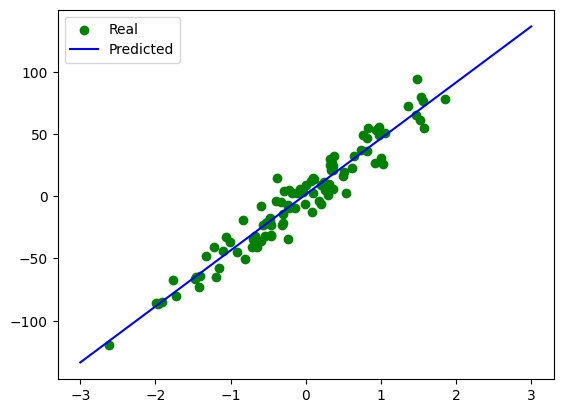

In [118]:
pred_line = w_true[0] * np.linspace(-3, 3, 100) + w_true[1]
plt.scatter(X_ones[:, 0], y, c='green', label='Real')
plt.plot(np.linspace(-3, 3, 100), np.squeeze(pred_line), c='blue', label='Predicted')
plt.legend()

### Now lets try to solve them via gradient descent 

Our first step will be to vizuialize the loss surface. 

In [119]:
coefficient_space = np.linspace(0, 100, 400)
intercept_space = np.linspace(-10, 20, 900)

grid_X, grid_y = np.meshgrid(coefficient_space, intercept_space)

# Reshape for broadcasting: grid is (M, N), X and y are (K,)
X_sq = X.squeeze().reshape(1, 1, -1)  # (1, 1, K)
y_exp = y.squeeze().reshape(1, 1, -1) # (1, 1, K)
grid_X_broadcasted = grid_X.reshape(grid_X.shape[0], grid_X.shape[1], 1)  # (M, N, 1)
grid_y_broadcasted = grid_y.reshape(grid_y.shape[0], grid_y.shape[1], 1)  # (M, N, 1)


residuals = y_exp - (grid_X_broadcasted * X_sq + grid_y_broadcasted)
loss = np.mean(residuals ** 2, axis=2)

In [121]:
def calculate_loss(coef, intercept):
    y_pred = coef * X.squeeze() + intercept
    return np.mean((y - y_pred) ** 2)

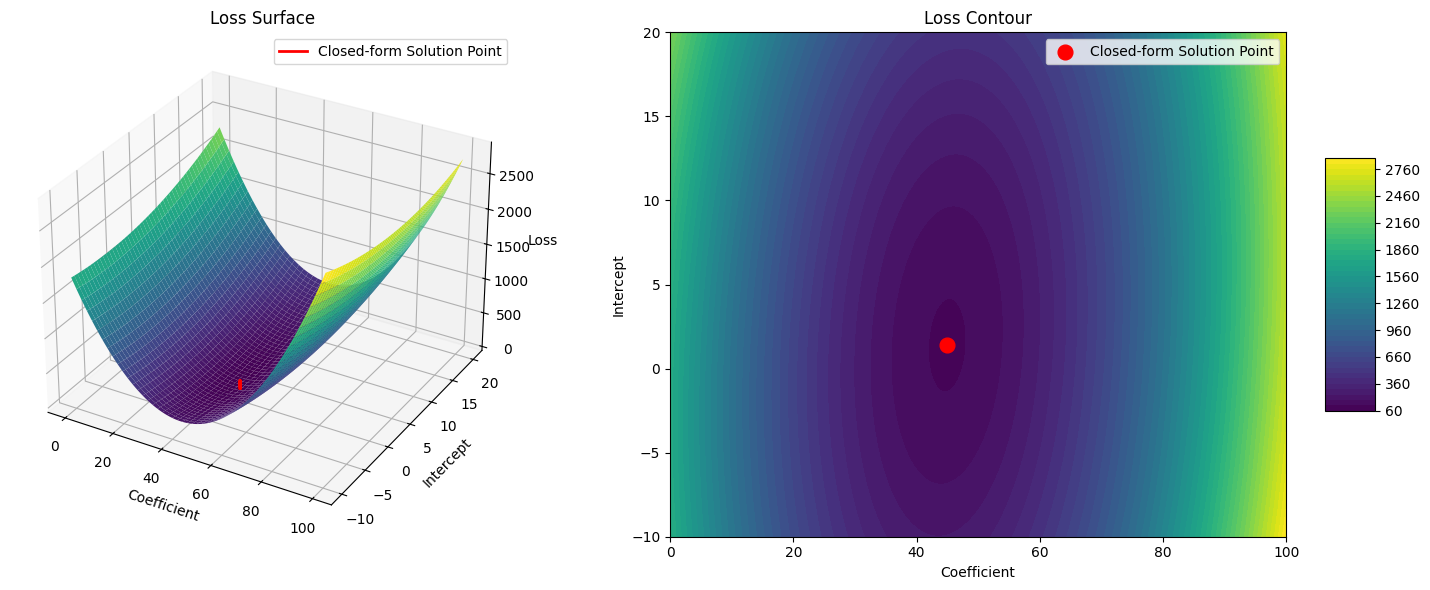

In [123]:
fig = plt.figure(figsize=(16, 6))
ax = fig.add_subplot(1, 2, 1, projection='3d')  
ax.plot_surface(grid_X, grid_y, loss, cmap='viridis', alpha=1.0)
ax.plot([ w_true[0], w_true[0]], [w_true[1], w_true[1]], [0, calculate_loss(w_true[0], w_true[1])], c='red', linewidth=2, zorder=10, label='Closed-form Solution Point')
ax.set_xlabel('Coefficient')
ax.set_ylabel('Intercept')
ax.set_zlabel('Loss')
ax.set_title('Loss Surface')
ax.legend()

ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(grid_X, grid_y, loss, levels=50, cmap='viridis')
ax2.scatter(w_true[0], w_true[1], calculate_loss(w_true[0], w_true[1]) , label='Closed-form Solution Point', color='red', zorder=5)
fig.colorbar(contour, ax=ax2, shrink=0.5, aspect=5)
ax2.legend()
ax2.set_xlabel('Coefficient')
ax2.set_ylabel('Intercept')
ax2.set_title('Loss Contour')

plt.tight_layout()
plt.show()

In [124]:
loss_at_w = calculate_loss(w_true[0], w_true[1])
print(f"Loss at w: {loss_at_w}")

Loss at w: 112.39812060658416


### Now let great out gradient based update equation

In [125]:
def upadte_w(w, learning_rate):
    coef, intercept = w[0] , w[1]
    y_pred = coef * X.squeeze() + intercept
    residuals = y - y_pred
     #MSE = sum((y - y_pred) ** 2) / len(y)
    # Calculate gradients
    d_coef =  -2 * np.mean(residuals * X.squeeze()) # derivative of MSE w.r.t. coefficient 
    d_intercept = -2 * np.mean(residuals) # derivative of MSE w.r.t. intercept
    
    # Update weights
    new_coef = coef - learning_rate * d_coef
    new_intercept = intercept - learning_rate * d_intercept
    
    return np.array([new_coef, new_intercept])

### Now lets check that is works

Closed-form solution w: [[44.97638393]
 [ 1.39813838]], Loss: 112.39812060658416
Epoch 50, w: [44.97638393  1.39813838], Loss: 112.39812060658414


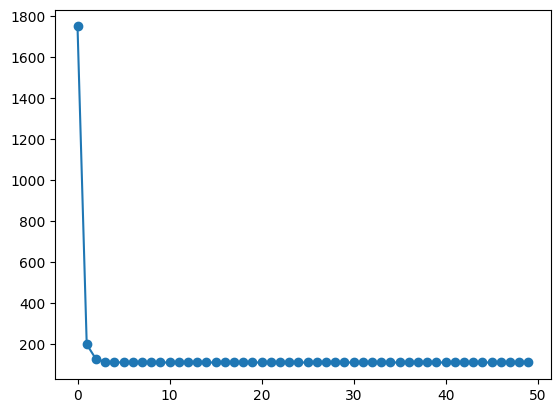

In [126]:
# lets try for lr=0.1
loss_history = []
w=np.random.rand(2)
for epoch in range(50):
    loss_history.append(calculate_loss(w[0], w[1]))
    w = upadte_w(w, learning_rate=0.7)

print(f"Closed-form solution w: {w_true}, Loss: {calculate_loss(w_true[0], w_true[1])}")
print(f"Epoch {epoch+1}, w: {w}, Loss: {loss_history[-1]}")
plt.plot(loss_history, marker='o')

## Now that we have built out this notebook, we will go on to talk about three things: 
1. How, depending on the learning, how close we can get to the true analytical solution value. 
2. How, depending on the learning rate, we can get to an unstable regime and never converge. 

### 1.

Lets have many different learning rates. Let's see if any of them ever get to the true solution EXECTLY. 

In [127]:
#run and get resutls for different learning rates
lrs = [0.0001, 0.001, 0.01, 0.1, 0.3, 0.5]
lr_losss = {}
for lr in lrs:
    loss_history = []
    w=np.random.rand(2)
    for epoch in range(25000):
        loss_history.append(calculate_loss(w[0], w[1]))
        w = upadte_w(w, learning_rate=lr)

    lr_losss[lr] = (loss_history, w)

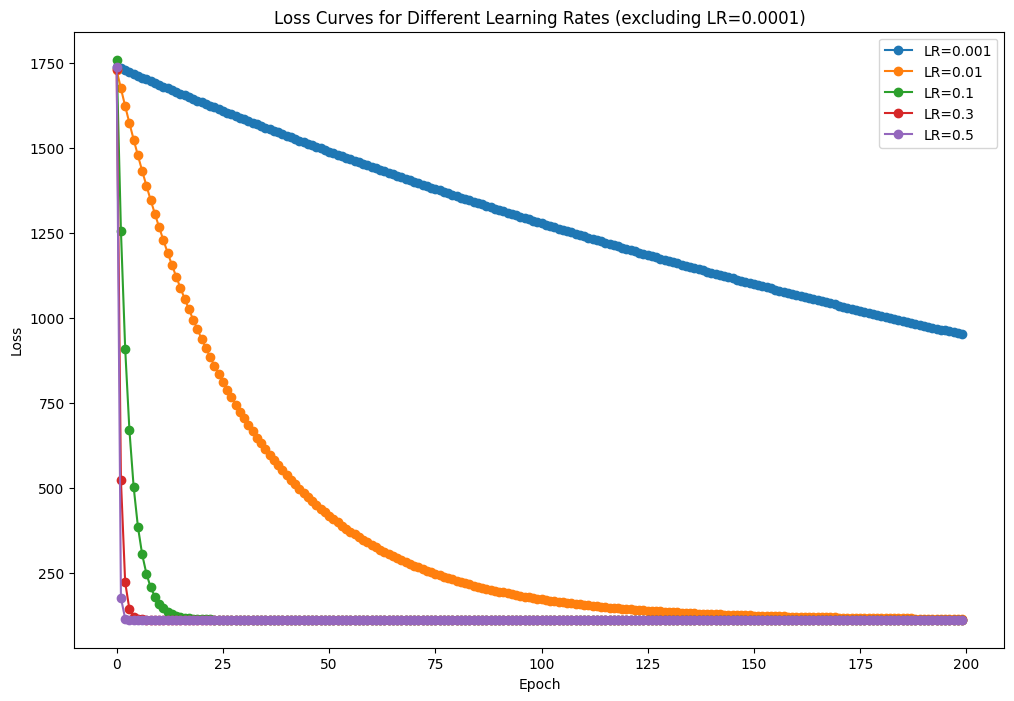

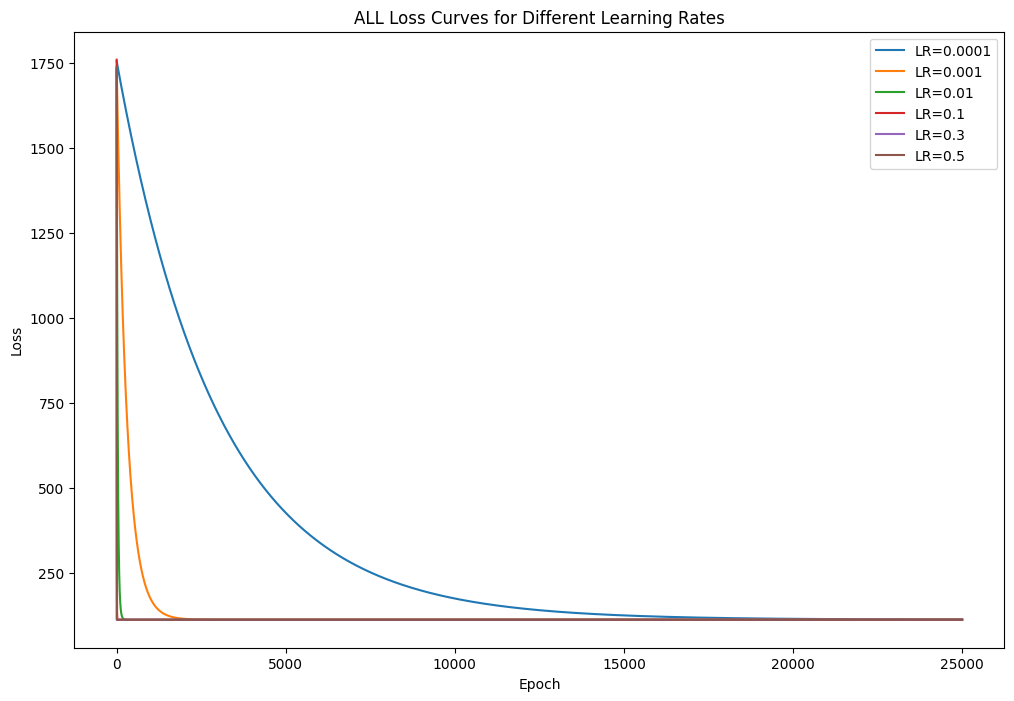

In [128]:
#plot loss curves for different learning rates

#plot with all but 0.0001
plt.figure(figsize=(12, 8))
for lr, (losses, _ ) in lr_losss.items():
    if lr == 0.0001:
        continue
    plt.plot(losses[:200], label=f'LR={lr}', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves for Different Learning Rates (excluding LR=0.0001)')
plt.legend()

#plot for all on the same graph
plt.figure(figsize=(12, 8))
for lr, (losses, _) in lr_losss.items():
    plt.plot(losses, label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ALL Loss Curves for Different Learning Rates')
plt.legend()

So you can see that the higher learning rates converge much faster, but let's see if any of them ever reach the true analytical solution exactly, and if so, when. 

In [129]:
print(f"True w: {w_true.squeeze()}")
print(f"Loss at true w: {calculate_loss(w_true[0], w_true[1])}")
print(f"Loss difference from true w: {calculate_loss(w_true[0], w_true[1]) - calculate_loss(w_true[0], w_true[1])}")
print(f"Weight difference from true w: {np.linalg.norm(w_true.squeeze() - w_true.squeeze())}")

True w: [44.97638393  1.39813838]
Loss at true w: 112.39812060658416
Loss difference from true w: 0.0
Weight difference from true w: 0.0


In [130]:
for lr, (losses, w) in lr_losss.items():
    print(f"LR: {lr}, Final Loss: {losses[-1]}")
    print(f"Loss difference from true w: {losses[-1] - calculate_loss(w_true[0], w_true[1])}")
    print(f"Weight difference from true w: {np.linalg.norm(w - w_true.squeeze())}")
    print("-"*40)


LR: 0.0001, Final Loss: 112.94015304929948
Loss difference from true w: 0.5420324427153247
Weight difference from true w: 0.8322383917499837
----------------------------------------
LR: 0.001, Final Loss: 112.39812060658419
Loss difference from true w: 2.842170943040401e-14
Weight difference from true w: 2.199603769219019e-12
----------------------------------------
LR: 0.01, Final Loss: 112.39812060658414
Loss difference from true w: -1.4210854715202004e-14
Weight difference from true w: 2.1487723471278227e-13
----------------------------------------
LR: 0.1, Final Loss: 112.39812060658416
Loss difference from true w: 0.0
Weight difference from true w: 2.140975221108325e-14
----------------------------------------
LR: 0.3, Final Loss: 112.39812060658416
Loss difference from true w: 0.0
Weight difference from true w: 7.108895957933346e-15
----------------------------------------
LR: 0.5, Final Loss: 112.39812060658414
Loss difference from true w: -1.4210854715202004e-14
Weight differen

Look, this is very interesting. Because we hypothesized that the lower learning rates would get closer to the true analytical solution, and in theory this is wrong since for vanilla gradient descent on a smooth convex problem any stable learning rate is guaranteed to converge to the same point. But we  get slightly different results due to floating-point operations. 


You could see that all the learning rates (except for the lowest learning rate) have pretty much converged to the same weight and same loss, plus or minus minimal differences. 

So every method — closed-form, fast LR, slow LR — hits a precision ceiling imposed by float64. They all get to essentially the same place. The only meaningful difference is how quickly they get there. (this holds just in the convex case)

In the non-convex case this no longer holds. Larger LRs might have momentum to jump over local minima, and smaller learning rates just descend to the local minima. So thats why learning rate schedules exist. You start high to explore the landscape broadly and avoid getting trapped in shallow minima, then anneal down to settle precisely into whatever basin you've found.

In [159]:
# So we will try againfor the learning rate that did not converge to the solution
lrs = [0.0001]
lr_losss_extra = {}
for lr in lrs:
    loss_history = []
    w=np.random.rand(2)
    for epoch in range(250000):
        loss_history.append(calculate_loss(w[0], w[1]))
        w = upadte_w(w, learning_rate=lr)

    lr_losss_extra[lr] = (loss_history, w)


In [160]:
for lr, (losses, w) in lr_losss_extra.items():
    print(f"LR: {lr}, Final Loss: {losses[-1]}")
    print(f"Loss difference from true w: {losses[-1] - calculate_loss(w_true[0], w_true[1])}")
    print(f"Weight difference from true w: {np.linalg.norm(w - w_true.squeeze())}")
    print("-"*40)

LR: 0.0001, Final Loss: 112.39812060658416
Loss difference from true w: 0.0
Weight difference from true w: 2.2002371789574378e-11
----------------------------------------


Sweet took longer, but it converged too!

### 2. Unstable learning rate. 

Let's just take a quick look. This is rather self-explanatory, but we will have a higher learning rate that is unstable, and you will see that it exits and never converges. 

Closed-form solution w: [[44.97638393]
 [ 1.39813838]], Loss: 112.39812060658416
Epoch 15, w: [ 75.85689043 -64.42473165], Loss: 4715.598854281732


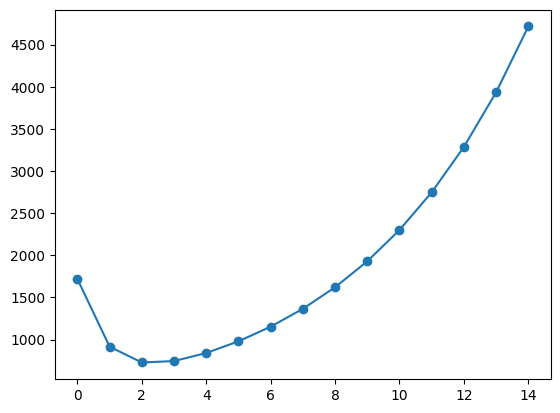

In [131]:
# lets try for lr=0.1
loss_history = []
w_history = []
w=np.random.rand(2)
for epoch in range(15):
    loss_history.append(calculate_loss(w[0], w[1]))
    w_history.append(w.copy())
    w = upadte_w(w, learning_rate=1.0)

print(f"Closed-form solution w: {w_true}, Loss: {calculate_loss(w_true[0], w_true[1])}")
print(f"Epoch {epoch+1}, w: {w}, Loss: {loss_history[-1]}")
plt.plot(loss_history, marker='o')

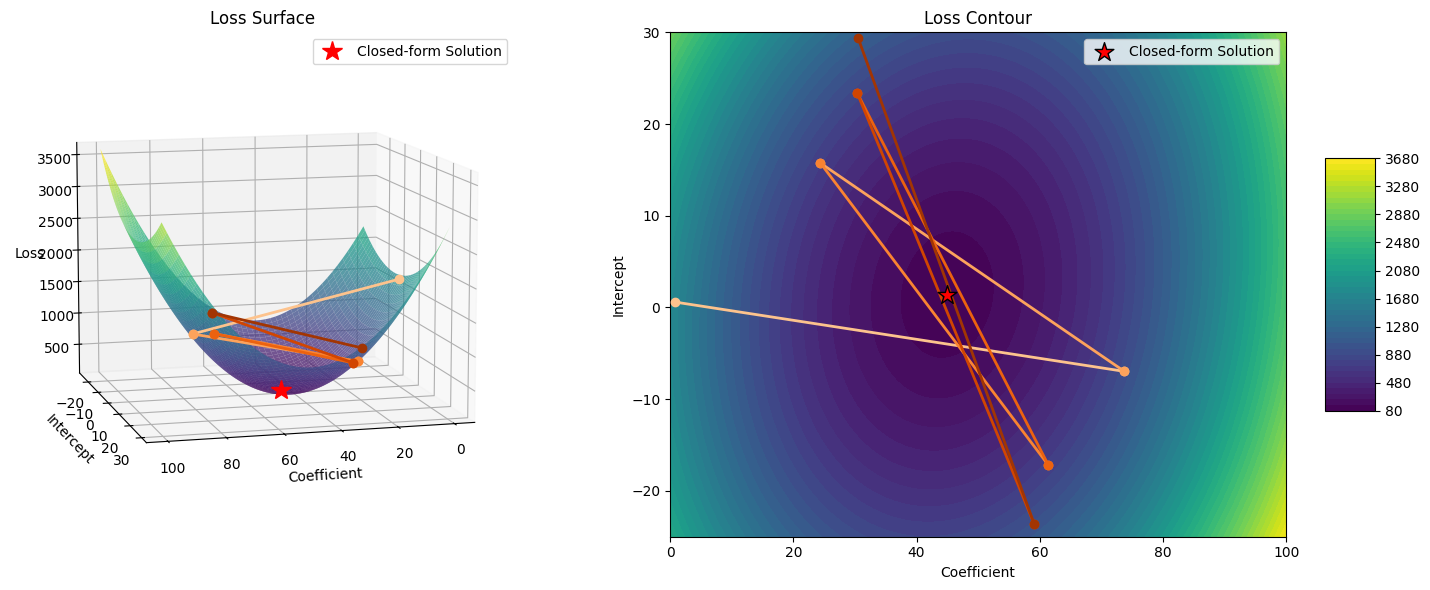

In [158]:
coefficient_space = np.linspace(0, 100, 400)
intercept_space = np.linspace(-25, 30, 900)

grid_X, grid_y = np.meshgrid(coefficient_space, intercept_space)

# Reshape for broadcasting: grid is (M, N), X and y are (K,)
X_sq = X.squeeze().reshape(1, 1, -1)  # (1, 1, K)
y_exp = y.squeeze().reshape(1, 1, -1) # (1, 1, K)
grid_X_broadcasted = grid_X.reshape(grid_X.shape[0], grid_X.shape[1], 1)  # (M, N, 1)
grid_y_broadcasted = grid_y.reshape(grid_y.shape[0], grid_y.shape[1], 1)  # (M, N, 1)


residuals = y_exp - (grid_X_broadcasted * X_sq + grid_y_broadcasted)
loss = np.mean(residuals ** 2, axis=2)

fig = plt.figure(figsize=(16, 6))

# 3D Surface
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(grid_X, grid_y, loss, cmap='viridis', alpha=0.75)

path = np.array(w_history[:7])
path_losses = [calculate_loss(w[0], w[1]) for w in path]

# Draw segments with gradient color
for i in range(len(path) - 1):
    color = plt.cm.Oranges(0.3 + 0.7 * i / (len(path) - 1))  # light to dark
    ax.plot(path[i:i+2, 0], path[i:i+2, 1], path_losses[i:i+2],
            'o-', color=color, markersize=6, linewidth=2, zorder=10)

ax.plot([w_true[0]], [w_true[1]], [calculate_loss(w_true[0], w_true[1])],
        'r*', markersize=15, zorder=10, label='Closed-form Solution')

ax.view_init(elev=10, azim=75)
ax.set_xlabel('Coefficient')
ax.set_ylabel('Intercept')
ax.set_zlabel('Loss')
ax.set_title('Loss Surface')
ax.legend()

# 2D Contour
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(grid_X, grid_y, loss, levels=50, cmap='viridis')
fig.colorbar(contour, ax=ax2, shrink=0.5, aspect=5)

for i in range(len(path) - 1):
    color = plt.cm.Oranges(0.3 + 0.7 * i / (len(path) - 1))
    ax2.plot(path[i:i+2, 0], path[i:i+2, 1], 'o-', color=color,
             markersize=6, linewidth=2, zorder=6)

ax2.scatter(w_true[0], w_true[1], c='red', s=200, marker='*',
            edgecolors='black', linewidths=1, zorder=10, label='Closed-form Solution')

ax2.set_xlabel('Coefficient')
ax2.set_ylabel('Intercept')
ax2.set_title('Loss Contour')
ax2.legend()

plt.tight_layout()
plt.show()


A nice visualization of the higher loss never converging. 